## Question 1: (0 Mark)
### Load the UCI Human Activity Recognition Dataset: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

In [1]:
import os
import pandas as pd
import os
base_path = "/Users/ravindramina/Desktop/DL 7/human+activity+recognition+using+smartphones/UCI HAR Dataset"
print(os.listdir(base_path))
X_train_path = os.path.join(base_path, "train", "X_train.txt")
y_train_path = os.path.join(base_path, "train", "y_train.txt")
X_test_path = os.path.join(base_path, "test", "X_test.txt")
y_test_path = os.path.join(base_path, "test", "y_test.txt")
features_path = os.path.join(base_path, "features.txt")
activity_labels_path = os.path.join(base_path, "activity_labels.txt")
#load feature names
features = pd.read_csv(features_path, sep=r"\s+", header=None)
feature_names = features[1].values
#load training data
X_train = pd.read_csv(X_train_path, sep=r"\s+", header=None)
y_train = pd.read_csv(y_train_path, sep=r"\s+", header=None, names=["Activity"])
#load test data
X_test = pd.read_csv(X_test_path, sep=r"\s+", header=None)
y_test = pd.read_csv(y_test_path, sep=r"\s+", header=None, names=["Activity"])

X_train.columns = feature_names
X_test.columns = feature_names

activity_labels = pd.read_csv(activity_labels_path, sep=r"\s+", header=None, names=["id", "activity"])
#map activity labels to names
activity_map = dict(zip(activity_labels.id, activity_labels.activity))

y_train["ActivityName"] = y_train["Activity"].map(activity_map)
y_test["ActivityName"] = y_test["Activity"].map(activity_map)
#verify
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nSample Data:")
print(X_train.head())

print("\nSample Labels:")
print(y_train.head())

['.DS_Store', 'test', 'features.txt', 'activity_labels.txt', 'features_info.txt', 'train', 'README.txt']
X_train shape: (7352, 561)
y_train shape: (7352, 2)
X_test shape: (2947, 561)
y_test shape: (2947, 2)

Sample Data:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.

## Question 2: (1 Mark)
## Show the class distribution of the dataset

In [2]:
print("Training Data Class Distribution:\n")
train_dist = y_train["ActivityName"].value_counts()
print(train_dist)
#class distribution in test set
print("\nTest Data Class Distribution:\n")
test_dist = y_test["ActivityName"].value_counts()
print(test_dist)

Training Data Class Distribution:

ActivityName
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Test Data Class Distribution:

ActivityName
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


## Question 3: (1 Mark)
## Divide the dataset into training validation and test sets: divide by the subject id such that out of 30 subjects, 20 subjects are in the training set, and 5 subjects are in the validation and test set respectively.

In [3]:
#load subject data
subject_train_path = os.path.join(base_path, "train", "subject_train.txt")
subject_test_path = os.path.join(base_path, "test", "subject_test.txt")
subject_train = pd.read_csv(subject_train_path, header=None, names=["subject"])
subject_test = pd.read_csv(subject_test_path, header=None, names=["subject"])

In [4]:
#combine all data
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)
subjects = pd.concat([subject_train, subject_test], ignore_index=True)

In [5]:
print(sorted(subjects["subject"].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [6]:
#define subject splits
train_subjects = list(range(1, 21))
val_subjects = list(range(21, 26))    #eg- 21–25
test_subjects = list(range(26, 31))  

In [7]:
#training set
X_train_new = X[subjects["subject"].isin(train_subjects)]
y_train_new = y[subjects["subject"].isin(train_subjects)]
#validation set
X_val = X[subjects["subject"].isin(val_subjects)]
y_val = y[subjects["subject"].isin(val_subjects)]
#test set
X_test_new = X[subjects["subject"].isin(test_subjects)]
y_test_new = y[subjects["subject"].isin(test_subjects)]

In [8]:
print("Train shape:", X_train_new.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test_new.shape)

Train shape: (6531, 561)
Validation shape: (1891, 561)
Test shape: (1877, 561)


## Question 4: (1 Marks)
## Standardize the features of the dataset.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_new)

## Question 5: (1 Marks)

## Design the data loaders for the training and validation sets.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

In [11]:
y_train_tensor = torch.tensor(y_train_new["Activity"].values - 1, dtype=torch.long)
y_val_tensor = torch.tensor(y_val["Activity"].values - 1, dtype=torch.long)

#convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

In [12]:
class HARDSataset(Dataset): #create a custom dataset class
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = HARDSataset(X_train_tensor, y_train_tensor)
val_dataset = HARDSataset(X_val_tensor, y_val_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) #create data loaders
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
#test dataloader
for X_batch, y_batch in train_loader:
    print("Batch X shape:", X_batch.shape)
    print("Batch y shape:", y_batch.shape)
    break

Batch X shape: torch.Size([64, 561])
Batch y shape: torch.Size([64])


## Question 6: (6 Marks)

## Design a GRU model from scratch (you can use PyTorch fc and activation layers, but not PyTorch’s GRU layer) to model this sequential dataset, and make predictions of the activity labels for each sample. use Epoch= 50, ,LR       = 1e-4, HIDDEN_SIZE = 64, NUM_LAYERS  = 2 and DROPOUT = 0.4.
##    • CrossEntropyLoss : standard for multi-class classification
##    • AdamW            : Adam with proper weight decay (better generalisation)
##    • LR scheduler     : reduces LR when val loss stops improving
##    • Gradient clipping: prevents exploding gradients in RNNs
##    • Best-model saving: we keep the checkpoint with lowest val loss

In [22]:
#reshape to sequence
def reshape_data(X):
    return X.view(X.shape[0], 33, 17)

X_train_seq = reshape_data(X_train_tensor)
X_val_seq = reshape_data(X_val_tensor)

In [ ]:
import torch
import torch.nn as nn

class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        
        self.W_z = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_r = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        combined = torch.cat([x, h_prev], dim=1)  
        z = torch.sigmoid(self.W_z(combined))
        r = torch.sigmoid(self.W_r(combined))
        combined_reset = torch.cat([x, r * h_prev], dim=1)
        h_tilde = torch.tanh(self.W_h(combined_reset))
        h_next = (1 - z) * h_prev + z * h_tilde
        return h_next

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers  
        self.cells = nn.ModuleList([
            GRUCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        h = [torch.zeros(batch_size, self.hidden_size).to(x.device)
             for _ in range(self.num_layers)]
        for t in range(seq_len):
            input_t = x[:, t, :]
            
            for i, cell in enumerate(self.cells):
                h[i] = cell(input_t, h[i])
                input_t = h[i]
        
        out = self.dropout(h[-1])
        out = self.fc(out)
        return out

In [28]:
model = GRUModel(
    input_size=17,   # 🔥 MUST BE 17
    hidden_size=64,
    num_layers=2,
    num_classes=6,
    dropout=0.4
)

In [ ]:
X_sample = reshape_data(X_train_tensor[:64])
out = model(X_sample)
print(out.shape)

torch.Size([64, 6])


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

In [ ]:
EPOCHS = 50
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    
    #train
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        #gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
#validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = reshape_data(X_batch).to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
#scheduler step
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_gru_model.pth")
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/50] | Train Loss: 1.6880 | Val Loss: 1.4952
Epoch [2/50] | Train Loss: 1.2952 | Val Loss: 1.1934
Epoch [3/50] | Train Loss: 1.1527 | Val Loss: 1.1361
Epoch [4/50] | Train Loss: 1.1104 | Val Loss: 1.0883
Epoch [5/50] | Train Loss: 1.0634 | Val Loss: 1.0255
Epoch [6/50] | Train Loss: 0.9919 | Val Loss: 0.9419
Epoch [7/50] | Train Loss: 0.9123 | Val Loss: 0.8609
Epoch [8/50] | Train Loss: 0.8470 | Val Loss: 0.8069
Epoch [9/50] | Train Loss: 0.8012 | Val Loss: 0.7719
Epoch [10/50] | Train Loss: 0.7667 | Val Loss: 0.7482
Epoch [11/50] | Train Loss: 0.7315 | Val Loss: 0.7289
Epoch [12/50] | Train Loss: 0.6991 | Val Loss: 0.7131
Epoch [13/50] | Train Loss: 0.6654 | Val Loss: 0.6778
Epoch [14/50] | Train Loss: 0.6293 | Val Loss: 0.6730
Epoch [15/50] | Train Loss: 0.5728 | Val Loss: 0.6369
Epoch [16/50] | Train Loss: 0.5437 | Val Loss: 0.6216
Epoch [17/50] | Train Loss: 0.4994 | Val Loss: 0.6031
Epoch [18/50] | Train Loss: 0.4752 | Val Loss: 0.5806
Epoch [19/50] | Train Loss: 0.4546 | 

## Question 7: (3 Marks)
## Train the GRU model designed from scratch on this dataset and plot the training and validation losses.

Early stopping at epoch 29


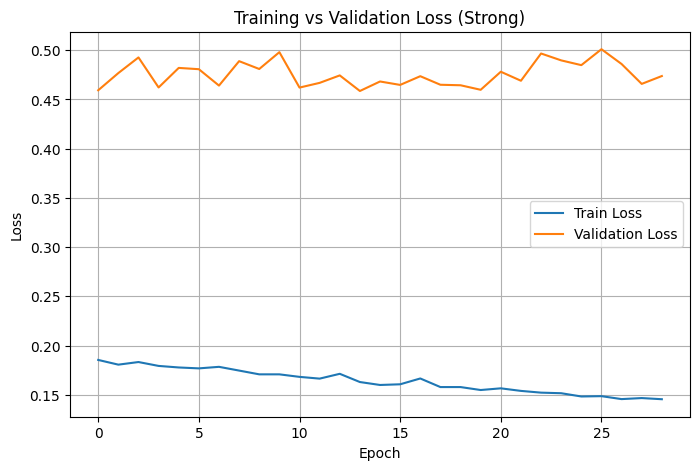

In [35]:
import torch
import matplotlib.pyplot as plt

EPOCHS = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 15   # 🔥 increased patience
counter = 0

# 🔥 slightly lower learning rate (better generalization)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

for epoch in range(EPOCHS):
#training
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
 #validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = reshape_data(X_batch).to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    #scheduler
    scheduler.step(val_loss)
    
    #model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_gru_model.pth")
        counter = 0
    else:
        counter += 1
    
    #early stopping
    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# load best model
model.load_state_dict(torch.load("best_gru_model.pth"))
#plot
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Strong)")
plt.legend()
plt.grid(True)
plt.show()

## Question 8: (2 Mark)
## Use the trained from-scratch GRU model to perform prediction on the test set. Report the precision, recall and show the confusion matrix.

Classification Report:

              precision    recall  f1-score   support

           0     0.9628    0.8993    0.9300       288
           1     0.8946    0.9705    0.9310       271
           2     0.9553    0.9400    0.9476       250
           3     0.9286    0.8743    0.9006       342
           4     0.8859    0.9356    0.9101       357
           5     1.0000    1.0000    1.0000       369

    accuracy                         0.9371      1877
   macro avg     0.9379    0.9366    0.9365      1877
weighted avg     0.9384    0.9371    0.9371      1877



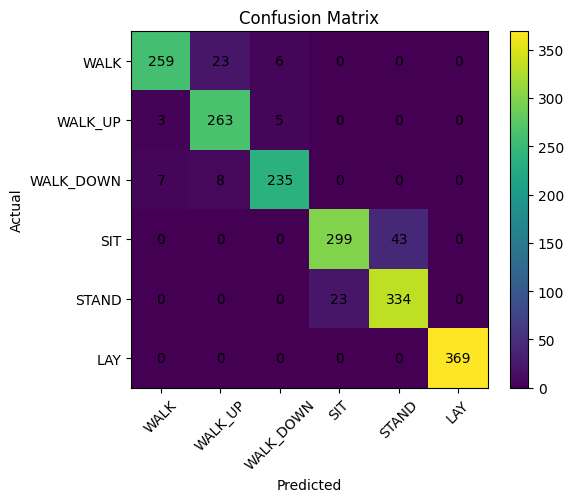

In [38]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
#test data tensors
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_new["Activity"].values - 1, dtype=torch.long)

test_dataset = HARDSataset(X_test_tensor, y_test_tensor)
#test loader
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
#best model load
model.load_state_dict(torch.load("best_gru_model.pth"))
model.eval()

all_preds = []
all_labels = []
#test predictions
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
#precision, recall
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4))
#confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["WALK", "WALK_UP", "WALK_DOWN", "SIT", "STAND", "LAY"]
ticks = np.arange(len(classes))

plt.xticks(ticks, classes, rotation=45)
plt.yticks(ticks, classes)

#annotate
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Question 9: (3 Marks)
## Implement the GRU model with the same architecture as the model designed from scratch using PyTorch’s GRU layer and train it, showing the training and validation losses.

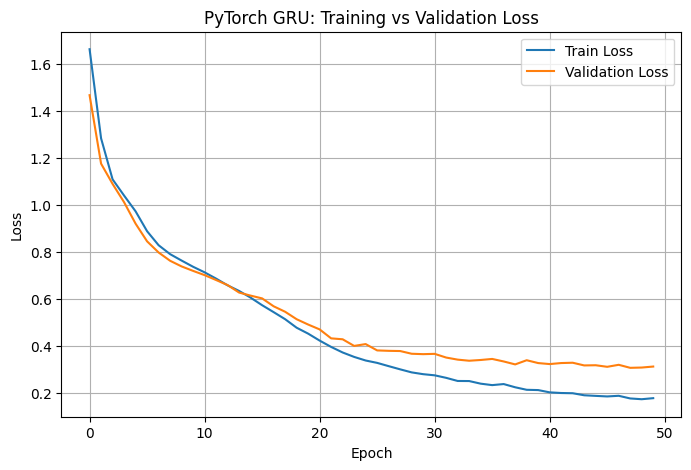

In [39]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
#model using PyTorch GRU
class GRUModelTorch(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]   # last timestep
        out = self.fc(out)
        return out

#init model
model_torch = GRUModelTorch(
    input_size=17,
    hidden_size=64,
    num_layers=2,
    num_classes=6,
    dropout=0.4
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_torch.parameters(), lr=1e-4, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)
#training loop
EPOCHS = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    
    #TRAIN
    model_torch.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_torch(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_torch.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    #VALIDATION
    model_torch.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = reshape_data(X_batch).to(device)
            y_batch = y_batch.to(device)
            
            outputs = model_torch(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
#save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_torch.state_dict(), "best_gru_torch.pth")
#plot
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch GRU: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Question 10: (1 Mark)
## Perform prediction on the test set using the model trained with PyTorch. Report the precision and recall of this model on the test set and show the confusion matrix.

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.8472    0.9173       288
           1     0.8297    0.9889    0.9024       271
           2     0.9752    0.9440    0.9593       250
           3     0.8411    0.8977    0.8685       342
           4     0.8952    0.8375    0.8654       357
           5     1.0000    1.0000    1.0000       369

    accuracy                         0.9180      1877
   macro avg     0.9235    0.9192    0.9188      1877
weighted avg     0.9232    0.9180    0.9182      1877



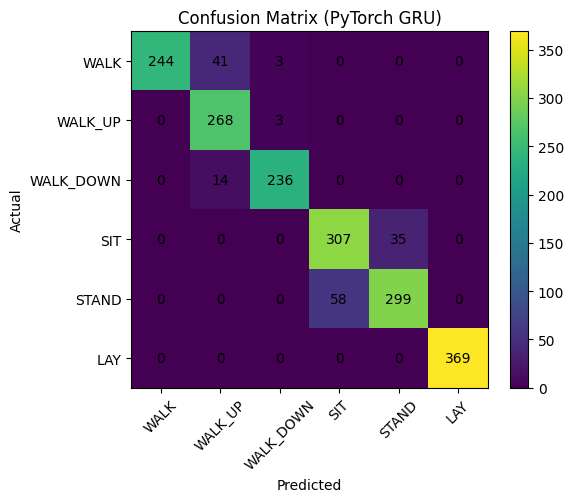

In [41]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
#load test data tensors
model_torch.load_state_dict(torch.load("best_gru_torch.pth"))
model_torch.eval()

all_preds = []
all_labels = []
#test predictions
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
        
        outputs = model_torch(X_batch)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
#precision, recall
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4))
#confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (PyTorch GRU)")
plt.colorbar()

classes = ["WALK", "WALK_UP", "WALK_DOWN", "SIT", "STAND", "LAY"]
ticks = np.arange(len(classes))

plt.xticks(ticks, classes, rotation=45)
plt.yticks(ticks, classes)

#annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Question 11: (1 Mark)
## Compare the performance of the GRU model you designed from scratch with that of the model designed using PyTorch’s GRU layer.

In [43]:
from sklearn.metrics import classification_report, accuracy_score
#load best models
model.load_state_dict(torch.load("best_gru_model.pth"))           
model_torch.load_state_dict(torch.load("best_gru_torch.pth"))     
model.eval()
model_torch.eval()
scratch_preds, torch_preds = [], []
true_labels = []
#get predictions from both models
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = reshape_data(X_batch).to(device)
        y_batch = y_batch.to(device)
#from-scratch GRU model
        out1 = model(X_batch)
        _, p1 = torch.max(out1, 1)
#PyTorch GRU model
        out2 = model_torch(X_batch)
        _, p2 = torch.max(out2, 1)
        
        scratch_preds.extend(p1.cpu().numpy())
        torch_preds.extend(p2.cpu().numpy())
        true_labels.extend(y_batch.cpu().numpy())
#accuracy comparison
acc_scratch = accuracy_score(true_labels, scratch_preds)
acc_torch = accuracy_score(true_labels, torch_preds)
print("Accuracy Comparison:")
print(f"From-Scratch GRU  : {acc_scratch:.4f}")
print(f"PyTorch GRU       : {acc_torch:.4f}")
#classification reports
print("\nFrom-Scratch GRU Report:\n")
print(classification_report(true_labels, scratch_preds, digits=4))

print("\nPyTorch GRU Report:\n")
print(classification_report(true_labels, torch_preds, digits=4))
#final conclusion
print("\nConclusion:")
if acc_torch > acc_scratch:
    print("PyTorch GRU performs better due to optimized implementation and stable training.")
elif acc_torch < acc_scratch:
    print("From-scratch GRU performs slightly better, showing correct custom implementation.")
else:
    print("Both models perform similarly with comparable accuracy.")

Accuracy Comparison:
From-Scratch GRU  : 0.9371
PyTorch GRU       : 0.9180

From-Scratch GRU Report:

              precision    recall  f1-score   support

           0     0.9628    0.8993    0.9300       288
           1     0.8946    0.9705    0.9310       271
           2     0.9553    0.9400    0.9476       250
           3     0.9286    0.8743    0.9006       342
           4     0.8859    0.9356    0.9101       357
           5     1.0000    1.0000    1.0000       369

    accuracy                         0.9371      1877
   macro avg     0.9379    0.9366    0.9365      1877
weighted avg     0.9384    0.9371    0.9371      1877


PyTorch GRU Report:

              precision    recall  f1-score   support

           0     1.0000    0.8472    0.9173       288
           1     0.8297    0.9889    0.9024       271
           2     0.9752    0.9440    0.9593       250
           3     0.8411    0.8977    0.8685       342
           4     0.8952    0.8375    0.8654       357
        